In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import hydropandas as hpd
from tsconfig import START_DATE, END_DATE, extent_to_rd, extent_to_ee
import numpy as np
import ee
import datetime
import pastas as ps


hpd.util.get_color_logger("INFO")

# pd.set_option("display.max_rows", None)
# pd.set_option("display.max_columns", None)
# pd.set_option("display.width", None)

<RootLogger root (INFO)>

In [2]:
organisation = "rotterdam"

auth = ("__key__", "D5aclEis.RBUeIvKA6jrLVUzNpPATjvGyLXsLAx7P")

In [3]:
my_extent = extent_to_rd() 
oc = hpd.read_lizard(
    extent=my_extent,
    which_timeseries=["hand", "diver", "diver_validated"],
    datafilters=None,
    combine_method="merge",
    organisation=organisation,
    auth=auth,
)

INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of monitoring wells: 12
INFO:hydropandas.io.lizard.get_obs_list_from_extent:Number of pages: 1


monitoring well: 100%|██████████| 12/12 [00:19<00:00,  1.62s/it]


In [4]:
oc.plots.interactive_map(
    color="red",
    zoom_start=15,
    tiles="Esri.WorldImagery",
    popup_width=350
)

In [5]:
oc

,x,y,location,filename,source,unit,tube_nr,screen_top,screen_bottom,ground_level,tube_top,metadata_available,obs,lat,lon
name,,,,,,,,,,,,,,,
GMW000000037926001,93189.909294,440646.828947,130571-99,,lizard,m NAP,1,-2.91,-4.91,-2.21,-2.41,True,GroundwaterObs GMW000000037926001 -----metadat...,51.950824,4.488096
GMW000000037928001,93169.289120,440666.928770,130571-98,,lizard,m NAP,1,-2.82,-4.82,-2.30,-2.32,True,GroundwaterObs GMW000000037928001 -----metadat...,51.951002,4.487792
GMW000000037937001,93118.429424,440492.229166,130571-96,,lizard,m NAP,1,-2.58,-4.58,-2.05,-2.08,True,GroundwaterObs GMW000000037937001 -----metadat...,51.949427,4.487084
GMW000000037939001,93213.649008,440628.729056,130571-100,,lizard,m NAP,1,-2.54,-4.54,-1.89,-2.04,True,GroundwaterObs GMW000000037939001 -----metadat...,51.950664,4.488444
GMW000000037940001,93283.319334,440695.628872,130571-102,,lizard,m NAP,1,-2.56,-4.56,-1.99,-2.06,True,GroundwaterObs GMW000000037940001 -----metadat...,51.951273,4.489446
GMW000000037941001,93234.359551,440659.228510,130571-101,,lizard,m NAP,1,-2.66,-4.66,-1.97,-2.16,True,GroundwaterObs GMW000000037941001 -----metadat...,51.950940,4.488740
GMW000000102664001,93153.539532,440540.226751,130571-9,,lizard,m NAP,1,-3.09,-4.09,-2.03,-2.09,True,GroundwaterObs GMW000000102664001 -----metadat...,51.949862,4.487586
GMW000000102816001,93154.459512,440540.706721,130571-92,,lizard,m NAP,1,-3.06,-5.06,-1.99,-2.06,True,GroundwaterObs GMW000000102816001 -----metadat...,51.949866,4.487599
GMW000000102876001,93352.969418,440644.496010,130571-93,,lizard,m NAP,1,-2.80,-4.80,-2.27,-2.30,True,GroundwaterObs GMW000000102876001 -----metadat...,51.950821,4.490468


In [6]:
gw = oc.obs["GMW000000037940001"]
print(gw)

GroundwaterObs GMW000000037940001
-----metadata------
name : GMW000000037940001 
x : 93283.31933403443 
y : 440695.62887220015 
location : 130571-102 
filename :  
source : lizard 
unit : m NAP 
tube_nr : 1 
screen_top : -2.56 
screen_bottom : -4.5600000000000005 
ground_level : -1.99 
tube_top : -2.06 
metadata_available : True 

-----time series------
                     value  flag  comment origin
peil_datum_tijd                                 
2015-05-22 23:00:00  -3.65   NaN  Gemeten   hand
2015-07-29 23:00:00  -3.65   NaN  Gemeten   hand
2015-08-13 23:00:00  -3.65   NaN  Gemeten   hand
2015-10-18 23:00:00  -3.43   NaN  Gemeten   hand
2015-11-04 10:35:00  -3.47   NaN  Gemeten   hand
...                    ...   ...      ...    ...
2026-01-06 05:27:13  -2.81   2.0           diver
2026-01-06 09:27:15  -2.81   2.0           diver
2026-01-06 13:27:17  -2.83   2.0           diver
2026-01-06 17:27:18  -2.82   2.0           diver
2026-01-07 09:27:25  -2.84   2.0           diver

[7026 

In [7]:
ts = gw["value"].copy()
ts.index = pd.to_datetime(ts.index)
ts = ts.dropna()

print(ts.index.min(), ts.index.max())
print(ts.shape)

2015-05-22 23:00:00 2026-01-07 09:27:25
(7015,)


In [8]:
ts_year = ts.loc[START_DATE:END_DATE]

ts_daily_raw = ts_year.resample("D").mean()

ts_daily = ts_daily_raw.interpolate(method="time")

is_interpolated = ts_daily_raw.isna()

In [9]:
percentile = 0.30

# === FIXED THRESHOLD ===
threshold_fixed = ts_year.quantile(percentile)

# === VARIABLE THRESHOLD ===
monthly_threshold = (
    ts_year
    .groupby(ts_year.index.month)
    .quantile(percentile)
    .reindex(range(1, 13))          # zorg dat alle maanden bestaan
)

n_months_with_data = monthly_threshold.notna().sum()

if n_months_with_data < 6:
    print(
        f"Not enough data for variable threshold ({n_months_with_data} months). "
        "Variable threshold will not be used."
    )
    threshold_variable_smooth = None
else:
    monthly_threshold = monthly_threshold.interpolate(method="linear")

    threshold_variable = ts_daily.index.to_series().map(
        lambda d: monthly_threshold.loc[d.month]
    )

    threshold_variable_smooth = (
        threshold_variable
        .rolling(window=20, min_periods=1)
        .mean()
    )

# === KIES welke threshold wordt gebruikt voor DROOGTE ===
threshold = threshold_variable_smooth if threshold_variable_smooth is not None else threshold_fixed


In [10]:
is_drought_fixed = ts_daily < threshold_fixed

if threshold_variable_smooth is not None:
    is_drought_variable = ts_daily < threshold_variable_smooth
else:
    is_drought_variable = None

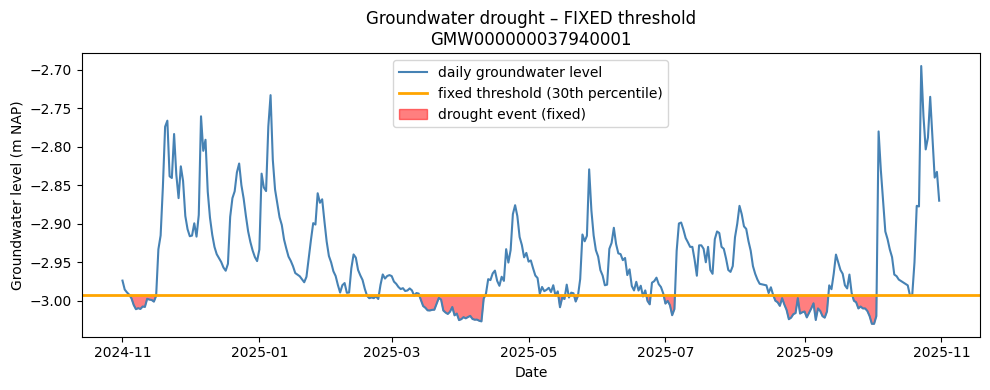

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    ts_daily.index,
    ts_daily,
    color="steelblue",
    linewidth=1.5,
    label="daily groundwater level",
)

ax.axhline(
    threshold_fixed,
    color="orange",
    linewidth=2,
    linestyle="-",
    label="fixed threshold (30th percentile)",
)

ax.fill_between(
    ts_daily.index,
    ts_daily,
    threshold_fixed,
    where=is_drought_fixed,
    color="red",
    alpha=0.5,
    label="drought event (fixed)",
    interpolate=True,
)

ax.set_ylabel("Groundwater level (m NAP)")
ax.set_xlabel("Date")
ax.set_title(f"Groundwater drought – FIXED threshold\n{gw.name}")
ax.legend()

plt.tight_layout()
plt.show()


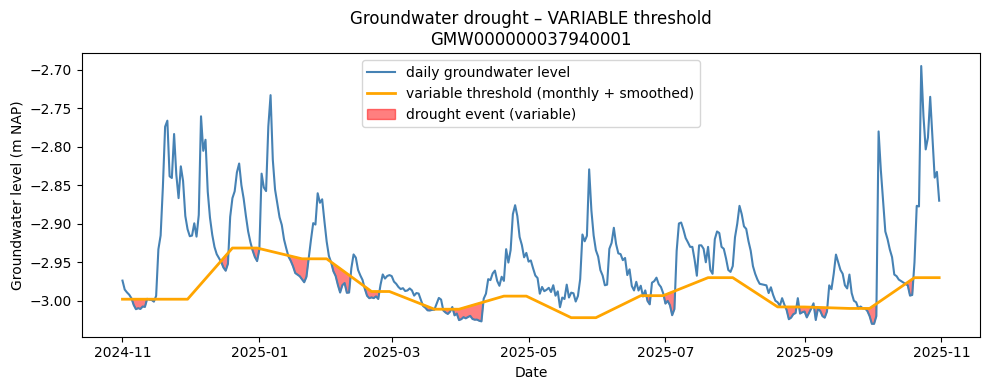

In [12]:
if threshold_variable_smooth is not None:
    fig, ax = plt.subplots(figsize=(10, 4))

    ax.plot(
        ts_daily.index,
        ts_daily,
        color="steelblue",
        linewidth=1.5,
        label="daily groundwater level",
    )

    ax.plot(
        threshold_variable_smooth.index,
        threshold_variable_smooth.values,
        color="orange",
        linewidth=2,
        label="variable threshold (monthly + smoothed)",
    )

    ax.fill_between(
        ts_daily.index,
        ts_daily,
        threshold_variable_smooth,
        where=is_drought_variable,
        color="red",
        alpha=0.5,
        label="drought event (variable)",
        interpolate=True,
    )

    ax.set_ylabel("Groundwater level (m NAP)")
    ax.set_xlabel("Date")
    ax.set_title(f"Groundwater drought – VARIABLE threshold\n{gw.name}")
    ax.legend()

    plt.tight_layout()
    plt.show()
else:
    print("Variable threshold plot skipped: insufficient data.")


In [13]:
# =========================
# SAMENVATTING – FIXED THRESHOLD
# =========================
duration_fixed = is_drought_fixed.sum()
max_deficit_fixed = (threshold_fixed - ts_daily[is_drought_fixed]).max()

n_interpolated = is_interpolated.sum()

print("=== FIXED THRESHOLD (30th percentile) ===")
print(
    f"Drought duration (2024–2025): {duration_fixed} days. "
    f"{n_interpolated} days were interpolated."
)
print(f"Maximum deficit (2024–2025): {max_deficit_fixed:.2f} m\n")


# =========================
# SAMENVATTING – VARIABLE THRESHOLD
# =========================
if is_drought_variable is not None:
    duration_variable = is_drought_variable.sum()
    max_deficit_variable = (
        threshold_variable_smooth - ts_daily[is_drought_variable]
    ).max()

    print("=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===")
    print(
        f"Drought duration (2024–2025): {duration_variable} days. "
        f"{n_interpolated} days were interpolated."
    )
    print(f"Maximum deficit (2024–2025): {max_deficit_variable:.2f} m\n")
else:
    print("=== VARIABLE THRESHOLD ===")
    print("Not enough data to compute variable threshold.\n")


# =========================
# DAGELIJKS OVERZICHT (WAARDES + HERKOMST)
# =========================
origin_per_day = (
    gw[["value", "origin"]]
    .dropna()
    .assign(date=lambda df: df.index.normalize())
    .groupby("date")["origin"]
    .agg(lambda x: ",".join(sorted(set(x))))
)

summary = pd.DataFrame({
    "value": ts_daily,
    "interpolated": is_interpolated,
})

summary["origin"] = origin_per_day
summary.loc[summary["interpolated"], "origin"] = "interpolated"

summary


=== FIXED THRESHOLD (30th percentile) ===
Drought duration (2024–2025): 99 days. 6 days were interpolated.
Maximum deficit (2024–2025): 0.04 m

=== VARIABLE THRESHOLD (monthly 30th percentile + smoothing) ===
Drought duration (2024–2025): 99 days. 6 days were interpolated.
Maximum deficit (2024–2025): 0.03 m



,value,interpolated,origin
peil_datum_tijd,,,
2024-11-01,-2.973833,False,diver_validated
2024-11-02,-2.985500,False,diver_validated
2024-11-03,-2.989167,False,diver_validated
2024-11-04,-2.992167,False,diver_validated
2024-11-05,-2.996833,False,diver_validated
...,...,...,...
2025-10-27,-2.735000,False,diver
2025-10-28,-2.786667,False,diver
2025-10-29,-2.840000,False,diver


In [14]:
project = 'afstuderen-481613'

try:
    ee.Initialize(project=project)
except:
    ee.Authenticate()
    ee.Initialize(project=project)

  dates = df_ts["date"].dt.to_pydatetime().tolist()



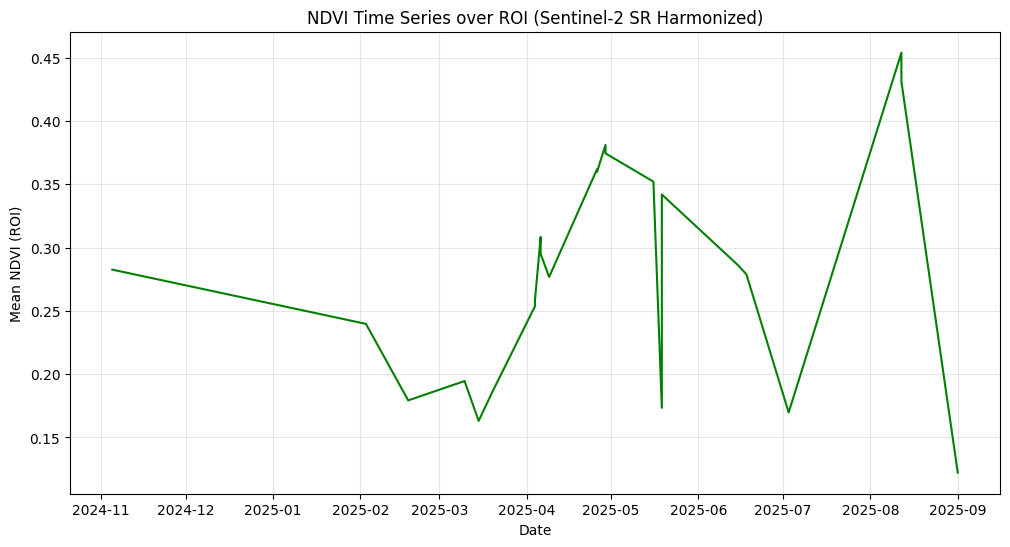

In [15]:
# Define region of interest
roi = ee.Geometry.Rectangle(extent_to_ee())

# Define time range
START_DATE = START_DATE
END_DATE = END_DATE

# --- Load Sentinel-2 SR Harmonized, filter in time/space ---
sentinel2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterDate(START_DATE, END_DATE)
    .filterBounds(roi)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))  # pas aan (10–30 is gebruikelijk)
)

# --- Cloud / shadow masking using SCL band ---
def mask_s2_clouds(image):
    scl = image.select("SCL")
    # Mask out: cloud shadow, clouds (low/med/high), cirrus, snow/ice
    mask = (
        scl.neq(3)
        .And(scl.neq(7))
        .And(scl.neq(8))
        .And(scl.neq(9))
        .And(scl.neq(10))
        .And(scl.neq(11))
    )
    return image.updateMask(mask)

sentinel2 = sentinel2.map(mask_s2_clouds)

# --- NDVI ---
def calculate_ndvi(image):
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI')
    return image.addBands(ndvi)

sentinel2_ndvi = sentinel2.map(calculate_ndvi)

# --- Reduce region (mean NDVI per image) ---
def reduce_region(image):
    stats = image.select('NDVI').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=roi,
        scale=10,          # B4/B8 zijn 10m
        bestEffort=True,
        maxPixels=1e13
    ).get('NDVI')
    date = ee.Date(image.get('system:time_start')).format('YYYY-MM-dd')
    return ee.Feature(None, properties={'date': date, 'NDVI': stats})

ndvi_ts = sentinel2_ndvi.map(reduce_region)

# --- Pull results as features to keep date <-> NDVI aligned ---
features = ee.FeatureCollection(ndvi_ts).getInfo()["features"]

dates = []
ndvi_values = []

for f in features:
    props = f.get("properties", {})
    d = props.get("date", None)
    v = props.get("NDVI", None)

    # skip missing values (e.g., fully masked ROI)
    if (d is None) or (v is None):
        continue

    dates.append(datetime.datetime.strptime(d, "%Y-%m-%d"))
    ndvi_values.append(float(v))

# --- Keep the rest of your workflow the same ---
# als je al een lijst 'dates' hebt (datetime objects)
df_ndvi_days = pd.DataFrame({
    "datum": pd.to_datetime(dates)
})

# --- 1) NDVI TIME SERIES PLOT (no standardization) ---
# Convert to numeric array, drop None values (cloudy dates may yield None)
ndvi_arr = np.array(ndvi_values, dtype="float64")

df_ts = pd.DataFrame({
    "date": pd.to_datetime(dates),
    "ndvi": ndvi_arr
}).dropna().sort_values("date")

# keep outputs consistent with your next cell expectations
dates = df_ts["date"].dt.to_pydatetime().tolist()
ndvi_values = df_ts["ndvi"].to_numpy()

plt.figure(figsize=(12, 6))
plt.plot(df_ts["date"], df_ts["ndvi"], color="green")
plt.xlabel("Date")
plt.ylabel("Mean NDVI (ROI)")
plt.title("NDVI Time Series over ROI (Sentinel-2 SR Harmonized)")
plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# Standardize ts_daily to [-1, 1]
ts_daily_standardized = ((ts_daily - ts_daily.min()) / (ts_daily.max() - ts_daily.min())) * 2 - 1

ndvi_values = np.array(ndvi_values)

# Standardize NDVI to [-1, 1]
ndvi_standardized = ((ndvi_values - min(ndvi_values)) / (max(ndvi_values) - min(ndvi_values))) * 2 - 1

INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (93283.31933403443, 440695.62887220015) and meteovariable RH
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for RH after 2026-01-07 01:00:00 and an end date of 2026-01-07 09:27:25 was requested. Changing end to 2026-01-07 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 344 has no measurements after 2026-01-07 01:00:00
INFO:hydropandas.io.knmi.get_knmi_obs:get KNMI data from station nearest to coordinates (93283.31933403443, 440695.62887220015) and meteovariable EV24
INFO:hydropandas.io.knmi.fill_missing_measurements:knmi station De Bilt has no measurements for EV24 after 2026-01-07 01:00:00 and an end date of 2026-01-07 09:27:25 was requested. Changing end to 2026-01-07 01:00:00
INFO:hydropandas.io.knmi._add_missing_indices:station 344 has no measurements after 2026-01-07 01:00:00


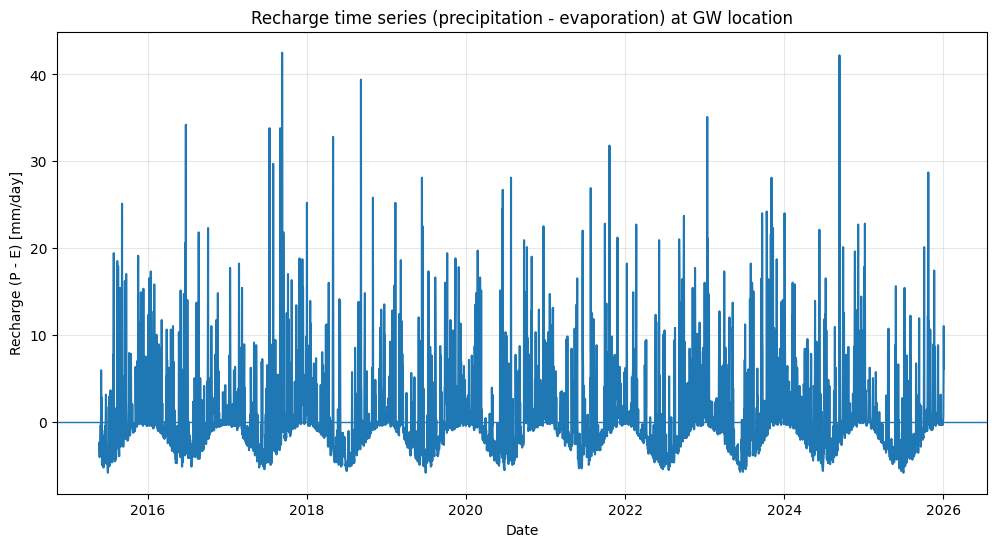

In [17]:
# Get the precipitation and evaporation data from the KNMI
precipitation = hpd.PrecipitationObs.from_knmi(
    xy=(gw.x, gw.y),
    start=gw.index[0],
    end=gw.index[-1],
    fill_missing_obs=True,
)
evaporation = hpd.EvaporationObs.from_knmi(
    xy=(gw.x, gw.y),
    meteo_var="EV24",
    start=gw.index[0],
    end=gw.index[-1],
    fill_missing_obs=True,
)

# --- Helper: extract the main timeseries column from a HydroPandas Obs (which is a DataFrame) ---
def _get_series_from_obs(o):
    # Prefer explicit meteo_var column if present
    col = getattr(o, "meteo_var", None)
    if col is not None and col in o.columns:
        return o[col].copy()

    # Otherwise pick first numeric-like column
    numeric_cols = list(o.select_dtypes(include="number").columns)
    if numeric_cols:
        return o[numeric_cols[0]].copy()

    # Fallback: first column
    return o[o.columns[0]].copy()

# Extract series
p = _get_series_from_obs(precipitation)
e = _get_series_from_obs(evaporation)

# Align on dates (inner join)
p, e = p.align(e, join="inner")

# Recharge (same unit as input, usually meters/day in hydropandas KNMI)
recharge = p - e
recharge.name = "recharge"

# Optional: convert to mm/day if your KNMI series are in meters/day
# (hydropandas KNMI examples show unit "m")  :contentReference[oaicite:1]{index=1}
recharge_mm = recharge * 1000.0

# Plot
plt.figure(figsize=(12, 6))
plt.plot(recharge_mm.index, recharge_mm.values)
plt.axhline(0, linewidth=1)
plt.xlabel("Date")
plt.ylabel("Recharge (P - E) [mm/day]")
plt.title("Recharge time series (precipitation - evaporation) at GW location")
plt.grid(True, alpha=0.3)
plt.show()

# # Create a Pastas Model
# ml = ps.Model(
#     gw.loc[gw["origin"] == "diver", "value"], name=gw.name
# )

# # Add the recharge data as explanatory variable
# ts1 = ps.RechargeModel(
#     precipitation["RH"].resample("D").first(),
#     evaporation["EV24"].resample("D").first(),
#     ps.Gamma(),
#     name="rainevap",
#     settings=("prec", "evap"),
# )

# # Add the stressmodel to the model and solve for period after 2015
# ml.add_stressmodel(ts1)
# ml.solve(tmin=START_DATE, tmax=END_DATE)
# ml.plots.results(figsize=(10, 6))

Recharge points to plot: 365


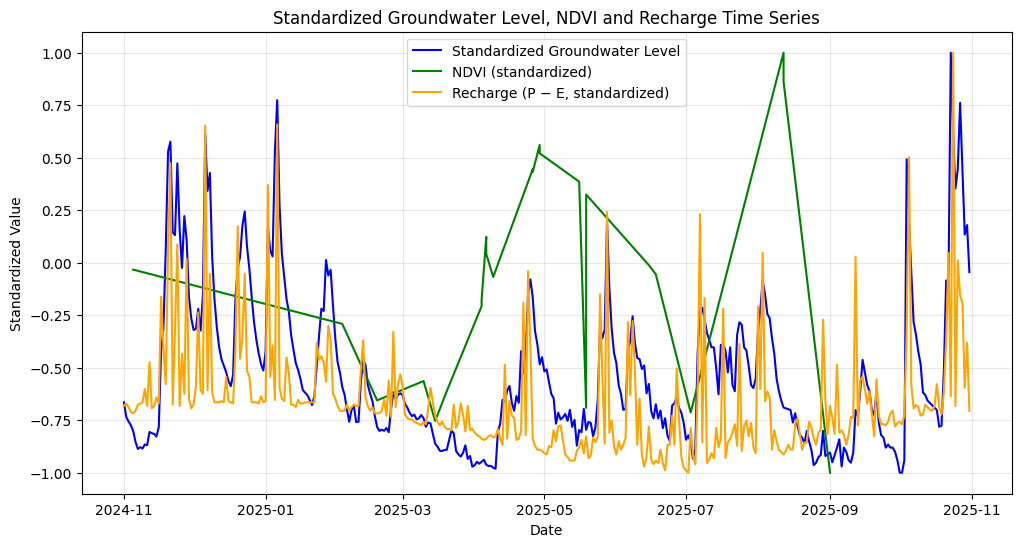

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def standardize_to_minus1_1(s: pd.Series) -> pd.Series:
    s = s.dropna()
    if len(s) == 0:
        return s
    mn, mx = s.min(), s.max()
    if mx == mn:
        # constante reeks -> zet alles op 0
        return pd.Series(0.0, index=s.index, name=s.name)
    return ((s - mn) / (mx - mn)) * 2 - 1

# --- Recharge: maak 'm daily en align met ts_daily.index ---
# 1) zorg voor nette datetime index + sort
recharge_series = recharge_mm.copy()
recharge_series.index = pd.to_datetime(recharge_series.index)
recharge_series = recharge_series[~recharge_series.index.duplicated(keep="first")].sort_index()

# 2) resample naar daily (als het al daily is: geen probleem)
recharge_daily = recharge_series.resample("D").mean()

# 3) align op ts_daily index
recharge_daily = recharge_daily.reindex(pd.to_datetime(ts_daily.index))

# 4) (optioneel) kleine gaten vullen zodat je een lijn krijgt
#    zet dit uit als je liever geen interpolatie wilt
recharge_daily = recharge_daily.interpolate(method="time", limit=14)

# --- Standaardiseer recharge ---
recharge_standardized = standardize_to_minus1_1(recharge_daily)
recharge_standardized.name = "Recharge (std)"

# --- Debug (handig): zie direct of 'ie leeg is ---
print("Recharge points to plot:", recharge_standardized.dropna().shape[0])

# --- Plot standardized ts_daily and NDVI (jouw stijl) + recharge ---
plt.figure(figsize=(12, 6))
plt.plot(ts_daily.index, ts_daily_standardized, label='Standardized Groundwater Level', color='blue')
plt.plot(dates, ndvi_standardized, label='NDVI (standardized)', color='green')
plt.plot(recharge_standardized.index, recharge_standardized.values, label='Recharge (P − E, standardized)', color='orange')

plt.xlabel('Date')
plt.ylabel('Standardized Value')
plt.title('Standardized Groundwater Level, NDVI and Recharge Time Series')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
